In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.datasets import load_wine
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score, precision_score


In [2]:
df = load_wine(as_frame=True).frame

df = df.iloc[:, [0, 1, -1]]
df.sample(2)

,alcohol,malic_acid,target
65,12.37,1.21,1
49,13.94,1.73,0


In [3]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

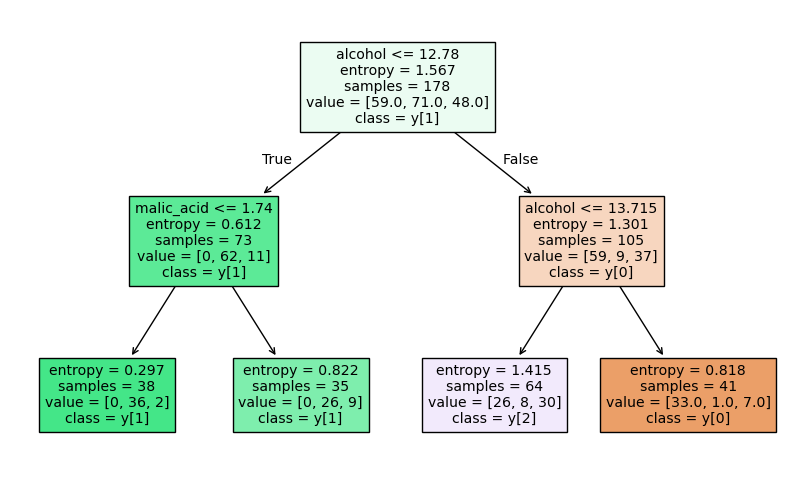

In [4]:
model = DecisionTreeClassifier(
    max_depth=2, 
    criterion='entropy',
    min_samples_split=50,
    min_samples_leaf=35,
    max_features='sqrt'
)
X = df.drop(columns='target')
y = df['target']
model.fit(X, y)

plt.figure(figsize=(10,6))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)
plt.show()


$$\text{Gain}_j = N_j \times \text{entropy}_j - (N_{\text{left}} \times \text{entropy}_{\text{left}} + N_{\text{right}} \times \text{entropy}_{\text{right}})$$ 
------------------------------


* Current Node: $\text{samples} = 178$, $\text{entropy} = 1.567$
* Left Child: $\text{samples} = 73$, $\text{entropy} = 0.612$
* Right Child: $\text{samples} = 105$, $\text{entropy} = 1.301$

$$\text{Gain}_{\text{root}} = (178 \times 1.567) - [(73 \times 0.612) + (105 \times 1.301)]$$ 
$$\text{Gain}_{\text{root}} = 278.926 - [44.676 + 136.605] = 278.926 - 181.281 = \mathbf{97.645}$$ 


* Current Node: $\text{samples} = 73$, $\text{entropy} = 0.612$
* Left Child: $\text{samples} = 31$, $\text{entropy} = 0.0$
* Right Child: $\text{samples} = 42$, $\text{entropy} = 0.83$

$$\text{Gain}_{\text{left\_sub}} = (73 \times 0.612) - [(31 \times 0.0) + (42 \times 0.83)]$$ 
$$\text{Gain}_{\text{left\_sub}} = 44.676 - [0 + 34.86] = \mathbf{9.816}$$ 

* Current Node: $\text{samples} = 105$, $\text{entropy} = 1.301$
* Left Child: $\text{samples} = 61$, $\text{entropy} = 0.851$
* Right Child: $\text{samples} = 44$, $\text{entropy} = 0.982$

$$\text{Gain}_{\text{right\_sub}} = (105 \times 1.301) - [(61 \times 0.851) + (44 \times 0.982)]$$ 
$$\text{Gain}_{\text{right\_sub}} = 136.605 - [51.911 + 43.208] = 136.605 - 95.119 = \mathbf{41.486}$$ 
------------------------------


* 
* alcohol: $\text{Gain}_{\text{root}} + \text{Gain}_{\text{left\_sub}} = 97.645 + 9.816 = \mathbf{107.461}$
* malic_acid: $\text{Gain}_{\text{right\_sub}} = \mathbf{41.486}$
* 

$$\text{Total Tree Gain} = 107.461 + 41.486 = \mathbf{148.947}$$ 
------------------------------

To get values between 0 and 1 that sum up to 100%:

* 
* Importance (alcohol) = $\frac{107.461}{148.947} \approx \mathbf{0.7215\ (72.15\%)}$
* Importance (malic_acid) = $\frac{41.486}{148.947} \approx \mathbf{0.2785\ (27.85\%)}$
* 

All other features present in your dataset that were not chosen for a split in this tree have an importance of 0.0%.

Out of all the total uncertainty (entropy) reduced by this entire tree, alcohol was responsible for 72.15% of that cleanup.

In [5]:
model.feature_importances_ 

array([0.96027965, 0.03972035])

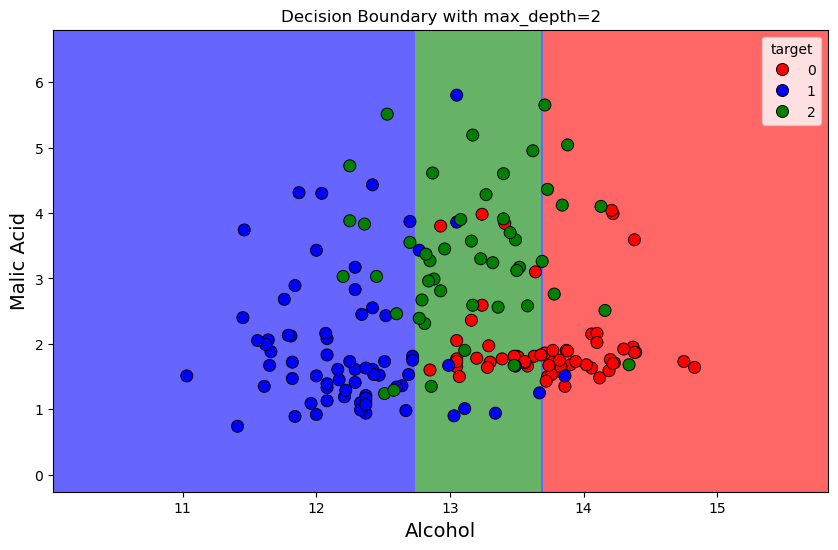

In [6]:
plt.figure(figsize=(10,6))
display_1 = DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', response_method='predict',
    cmap=ListedColormap(['red', 'blue', 'green']), alpha=0.6,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='alcohol', y='malic_acid', hue='target',
    palette=['red','blue','green'], s=75, edgecolor='k'
)
plt.xlabel('Alcohol', fontsize=14)
plt.ylabel('Malic Acid', fontsize=14)
plt.title('Decision Boundary with max_depth=2')
plt.show()

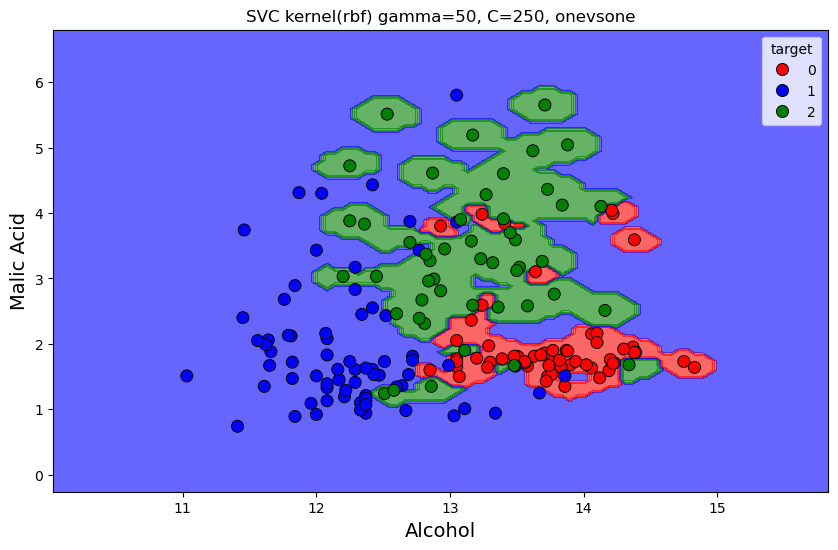

In [7]:
model_2 = SVC(
    kernel='rbf',
    decision_function_shape='ovo',
    C=250,
    gamma=50
)
model_2.fit(X, y)
plt.figure(figsize=(10,6))
display_1 = DecisionBoundaryDisplay.from_estimator(
    model_2, X,
    plot_method='contourf', response_method='predict', class_of_interest=2,
    cmap=ListedColormap(['red', 'blue', 'green']), alpha=0.6,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='alcohol', y='malic_acid', hue='target',
    palette=['red','blue','green'], s=75, edgecolor='k'
)
plt.xlabel('Alcohol', fontsize=14)
plt.ylabel('Malic Acid', fontsize=14)
plt.title('SVC kernel(rbf) gamma=50, C=250, onevsone')
plt.show()

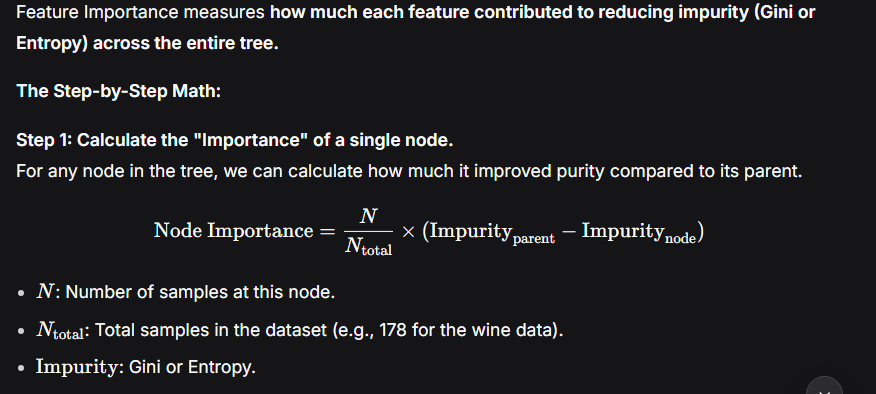

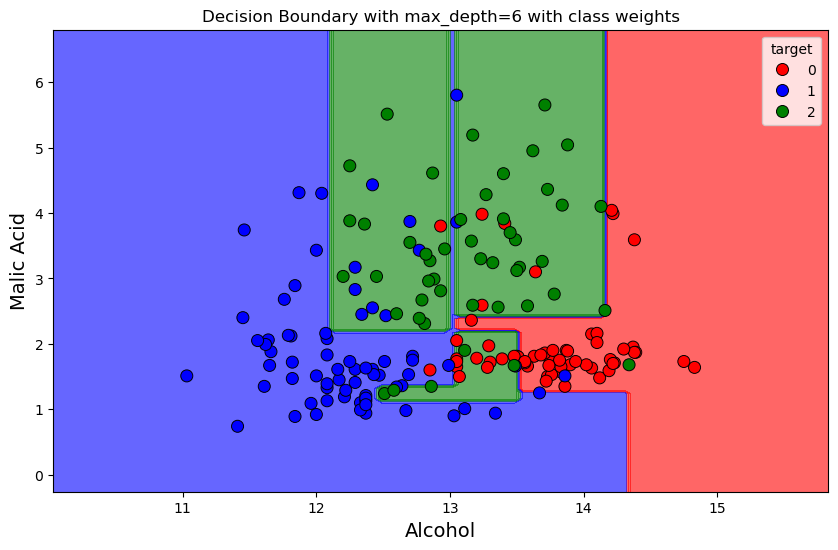

In [8]:
model = DecisionTreeClassifier(
    random_state=26,
    max_depth=6, 
    criterion='entropy',
    splitter='best', 
    class_weight={0: 1, 1: 2, 2: 10} 
)
model.fit(X, y)

plt.figure(figsize=(10,6))
display_1 = DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', response_method='predict',
    cmap=ListedColormap(['red', 'blue', 'green']), alpha=0.6,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='alcohol', y='malic_acid', hue='target',
    palette=['red','blue','green'], s=75, edgecolor='k'
)
plt.xlabel('Alcohol', fontsize=14)
plt.ylabel('Malic Acid', fontsize=14)
plt.title('Decision Boundary with max_depth=6 with class weights')
plt.show()

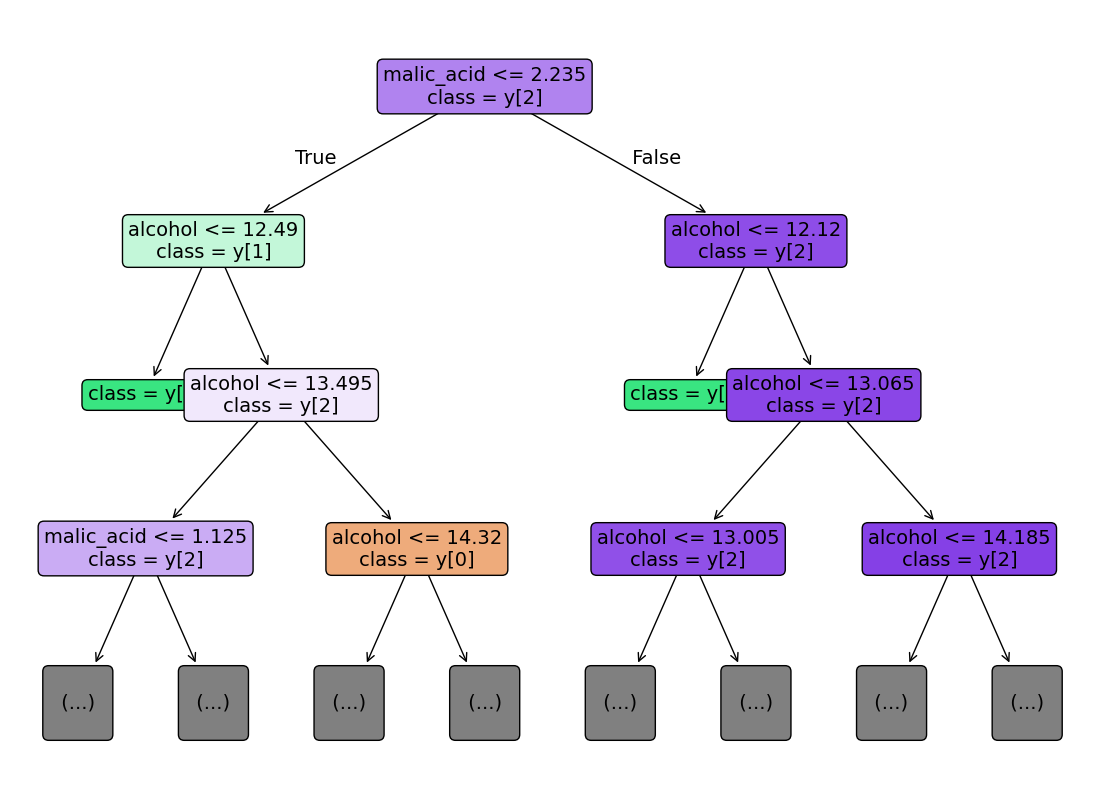

In [9]:
plt.figure(figsize=(14, 10))
annotations = plot_tree(
    model,
    feature_names=X.columns,
    label="all", 
    class_names=True,
    filled=True,
    fontsize=14,
    rounded=True,
    max_depth=3,
    impurity=False
)

for text in annotations:
    lines = text.get_text().split("\n")
    filtered_lines = [
        line
        for line in lines
        if not (line.startswith("samples") or line.startswith("value"))
    ]
    text.set_text("\n".join(filtered_lines))
plt.show()

In [10]:
model.feature_importances_

array([0.57043694, 0.42956306])

# DATASET

In [11]:
file_path = r'C:\Users\hp\Downloads\estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition\ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(file_path)
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [13]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


FCVC is how often they eat vegetables, NCP number of meals per day, CH2O numbers of water in liters per day

FAF Physical activity times per week

TUE time spent on phone on hour per day

In [14]:
df['FCVC'].value_counts()

FCVC
3.000000    652
2.000000    600
1.000000     33
2.823179      2
2.214980      2
           ... 
2.927409      1
2.706134      1
2.010684      1
2.300408      1
2.680375      1
Name: count, Length: 810, dtype: int64

In [15]:
df['NObeyesdad'].value_counts(normalize=True, ascending=True)

NObeyesdad
Insufficient_Weight    0.128849
Normal_Weight          0.135955
Overweight_Level_I     0.137376
Overweight_Level_II    0.137376
Obesity_Type_II        0.140692
Obesity_Type_III       0.153482
Obesity_Type_I         0.166272
Name: proportion, dtype: float64

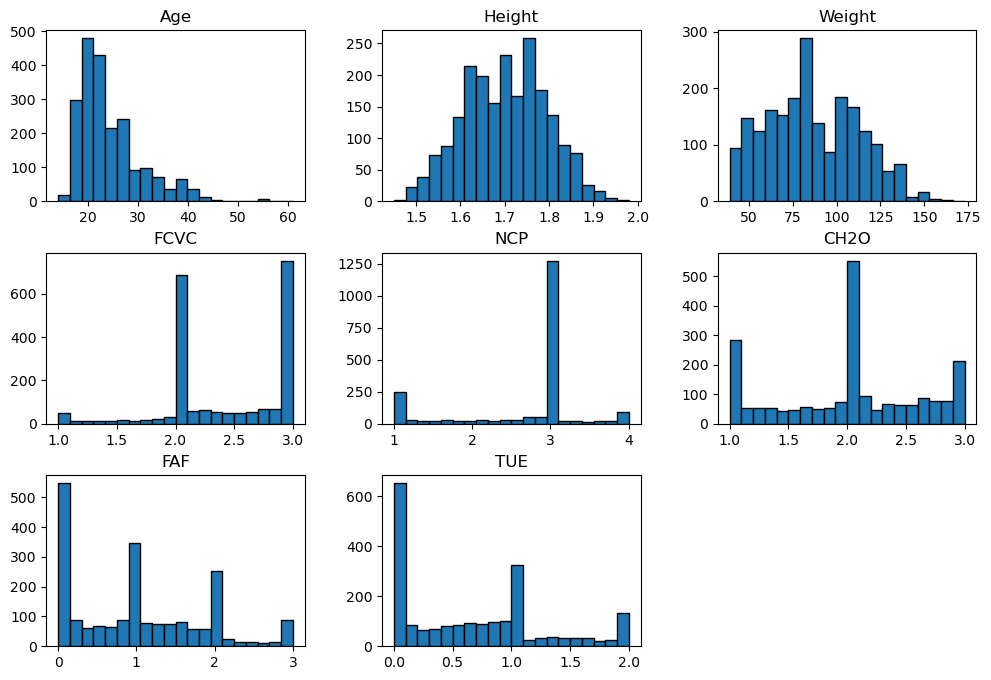

In [16]:
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols].hist(bins=20, edgecolor='k', grid=False, figsize=(12,8))
plt.show()

In [17]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols].describe()

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


FAVC Frequent consumption of high caloric food

CALC (Consumption of alcohol)

MTRANS (Transportation used)

CAEC (Consumption of food between meals) eg snacks

SCC (Calories Consumption Monitoring) do the person track his diet 

In [18]:
# Rounding the survey measurements

df['FCVC'] = df['FCVC'].round()
df['NCP'] = df['NCP'].round()
df['CH2O'] = df['CH2O'].round()
df['FAF'] = df['FAF'].round()
df['TUE'] = df['TUE'].round()

In [19]:
df['CALC'].value_counts()

CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

In [20]:
y = df[['NObeyesdad']]
diet_track = df[['SCC']]
alcohol = df[['CALC']]

enc = OrdinalEncoder(categories=[[
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]])
enc_2 = OrdinalEncoder(
    categories=[['yes', 'no']]
)
enc_3 = OrdinalEncoder(
    categories=[['no', 'Sometimes', 'Frequently', 'Always']]
)
y = enc.fit_transform(y)
diet_track = enc_2.fit_transform(diet_track)
alcohol = enc_3.fit_transform(alcohol)

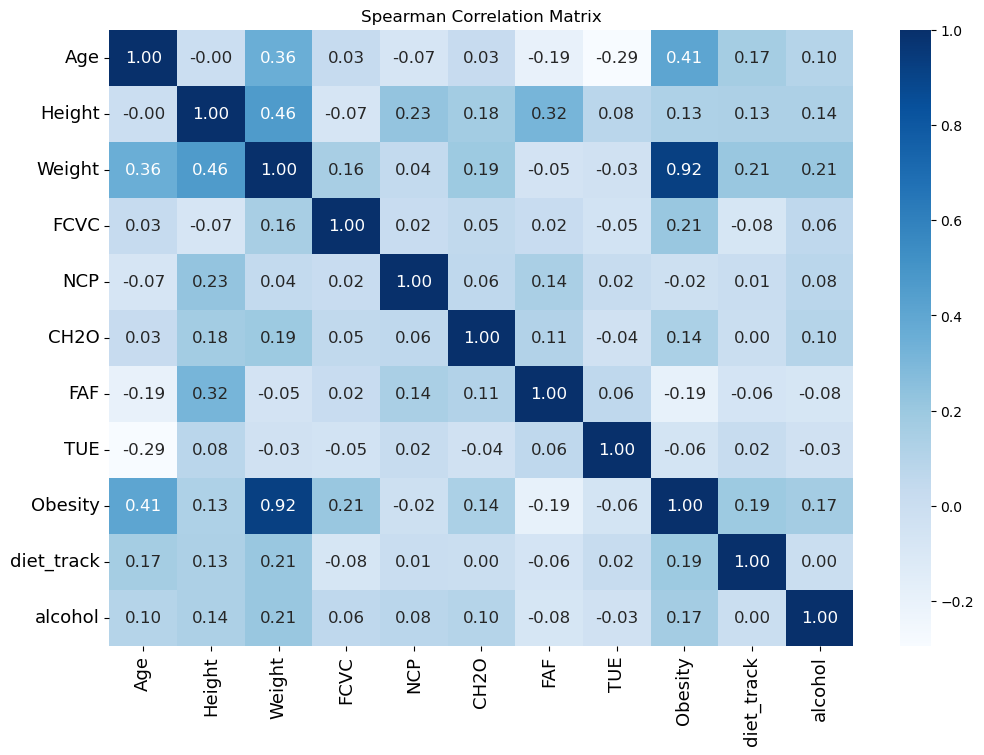

In [21]:
X = df[numeric_cols].copy()
X['Obesity'] = y
X['diet_track'] = diet_track
X['alcohol']= alcohol
corr = X.corr(numeric_only=True, method='spearman')
plt.figure(figsize=(12,8))
ax = sns.heatmap(data=corr, cmap='Blues', annot=True, annot_kws={'size': 12}, fmt='.2f')
plt.title('Spearman Correlation Matrix')
ax.tick_params(axis='both', labelsize=13)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [22]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

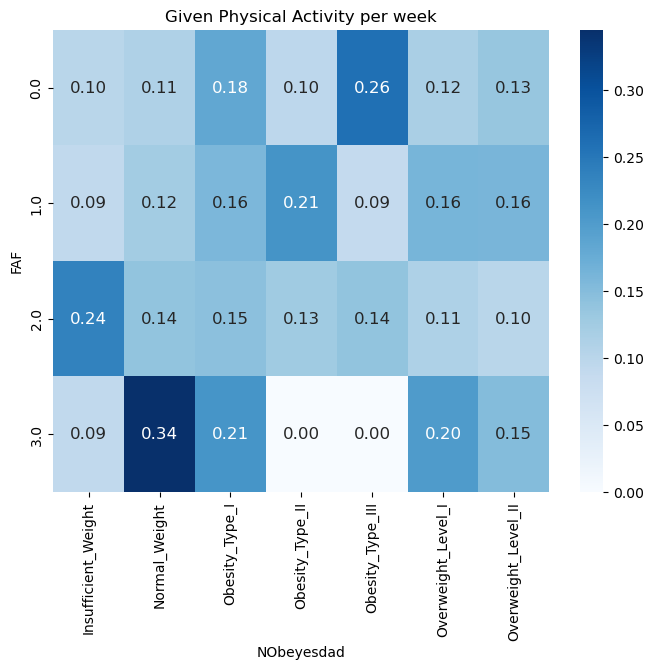

In [23]:
cross = pd.crosstab(df['FAF'], df['NObeyesdad'], normalize='index')
plt.figure(figsize=(8,6))
sns.heatmap(data=cross, cmap='Blues', annot=True, annot_kws={'size': 12}, fmt='.2f')
plt.title("Given Physical Activity per week")
plt.show()


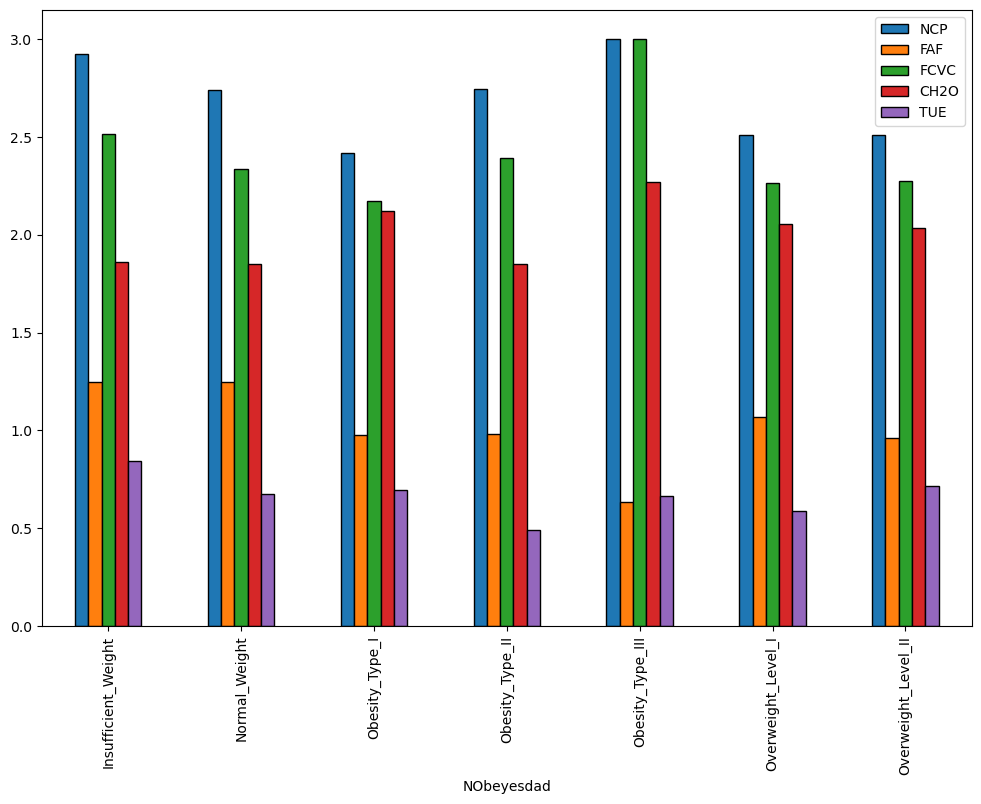

In [24]:
df.groupby(['NObeyesdad'])[['NCP', 'FAF', 'FCVC', 'CH2O', 'TUE']].mean().plot(
    kind='bar', figsize=(12,8), edgecolor='k')
plt.show()

In [25]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

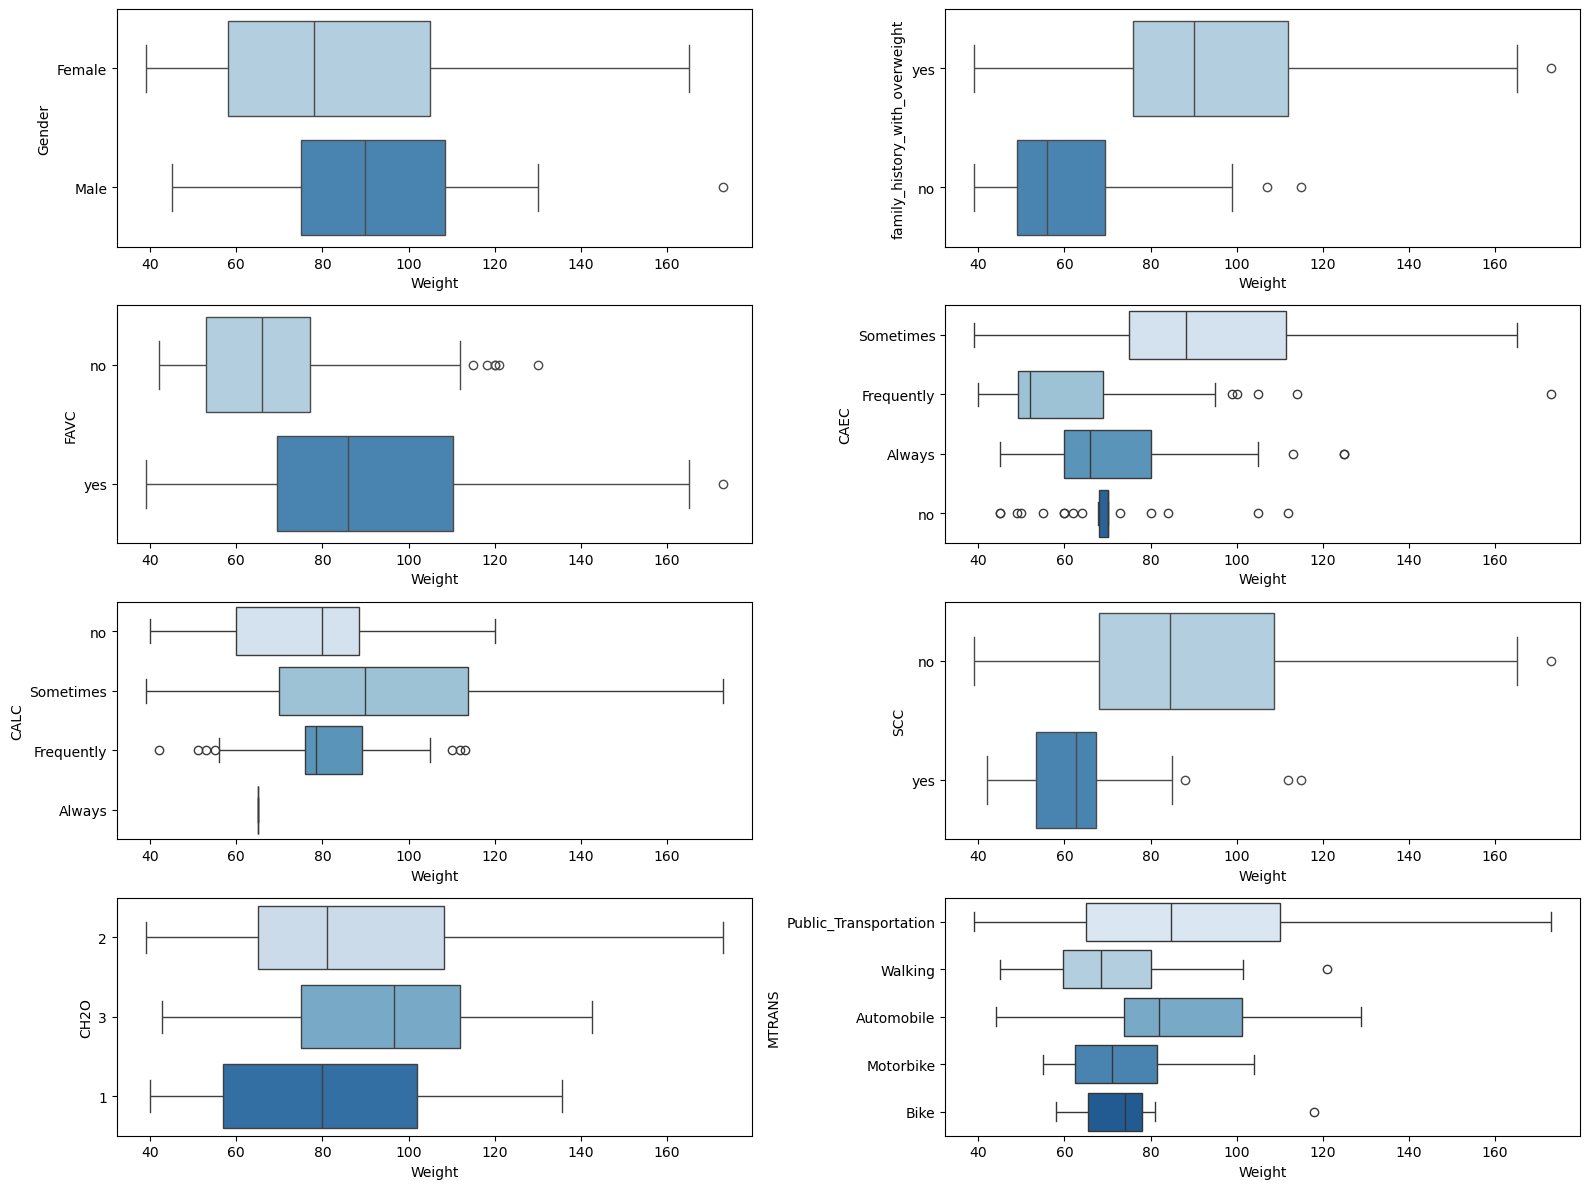

In [26]:
df_plot = df.copy()
df_plot['CH2O'] = df_plot['CH2O'].round().astype(int).astype(str)

columns = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'CALC', 'SCC', 'CH2O', 'MTRANS']

fig, ax = plt.subplots(4, 2, figsize=(16, 12))
ax = ax.flatten()
for idx, val in enumerate(columns):
    sns.boxplot(
        data=df_plot, x='Weight', y=val, hue=val,
        ax=ax[idx], palette='Blues', legend=False
    )
plt.tight_layout()
plt.show()

In [27]:
#Feature Engineering

df['BMI'] = df['Weight']/(df['Height']**2)


In [28]:
df.drop(columns=['Height', 'Weight'], inplace=True)

In [29]:
ordinal_cols = ['CAEC', 'CALC']
nominal_cols = ['family_history_with_overweight', 'Gender', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']

preprocessing = ColumnTransformer(
    transformers=[
        ('Ordinal', OrdinalEncoder(categories=[
            ['no', 'Sometimes', 'Frequently', 'Always'],
            ['no', 'Sometimes', 'Frequently', 'Always']  
        ]), ordinal_cols),
        ('Nominal', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), nominal_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', DecisionTreeClassifier(criterion='entropy', max_depth=3)),
    ])

X = df.drop(columns='NObeyesdad')
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=26, shuffle=True, 
    stratify=y
)

pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Ordinal', ...), ('Nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


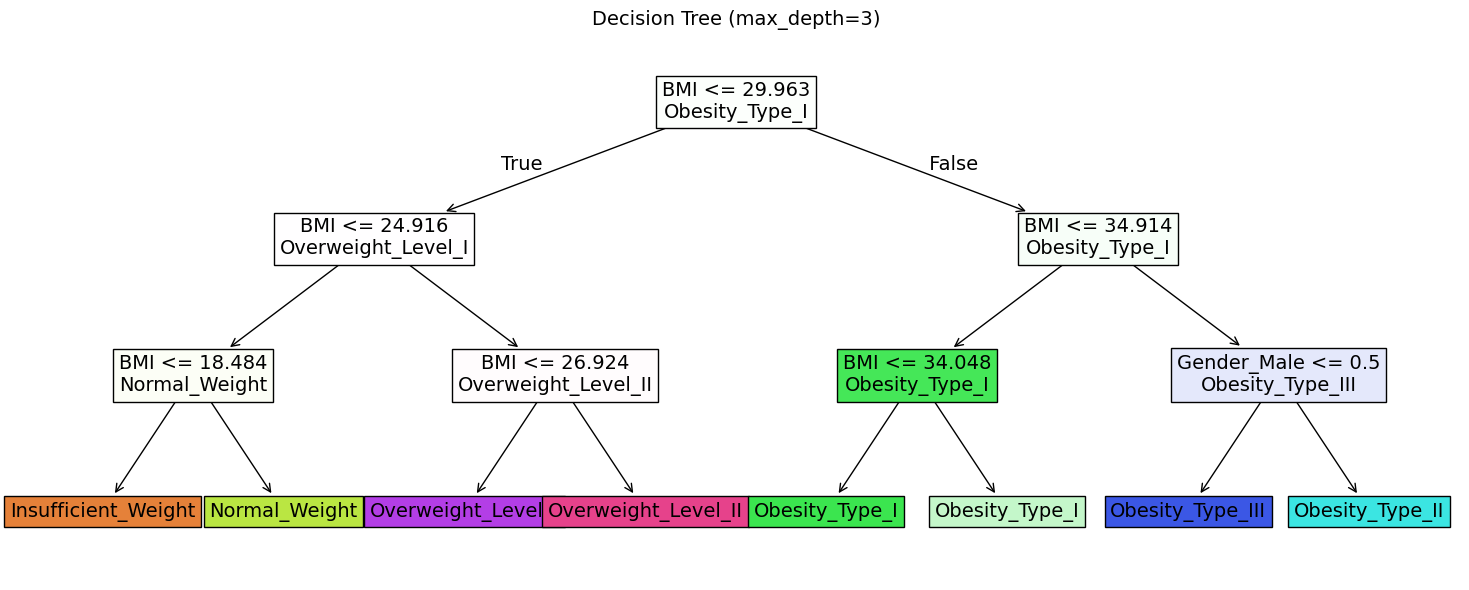

In [30]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(
    pipeline.named_steps['model'],
    feature_names=feature_names,
    class_names=pipeline.named_steps['model'].classes_,
    max_depth=3,
    filled=True,
    fontsize=14,
    impurity=False,
    ax=ax
)

for text_obj in ax.texts:
    lines = text_obj.get_text().split('\n')
    filtered_lines = []
    
    for line in lines:
        s = line.strip()
        if (
            s.isdigit() or 
            '[' in s or ']' in s or 
            any(k in s.lower() for k in ['samples', 'value', 'entropy', 'gini'])
        ):
            continue

        if 'class =' in line:
            line = line.replace('class =', '').strip()
            
        filtered_lines.append(line)
        
    text_obj.set_text('\n'.join(filtered_lines))

plt.title('Decision Tree (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
df[df['BMI'] <=29]['NObeyesdad'].value_counts()

NObeyesdad
Overweight_Level_I     290
Normal_Weight          287
Insufficient_Weight    272
Overweight_Level_II    236
Name: count, dtype: int64

In [32]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

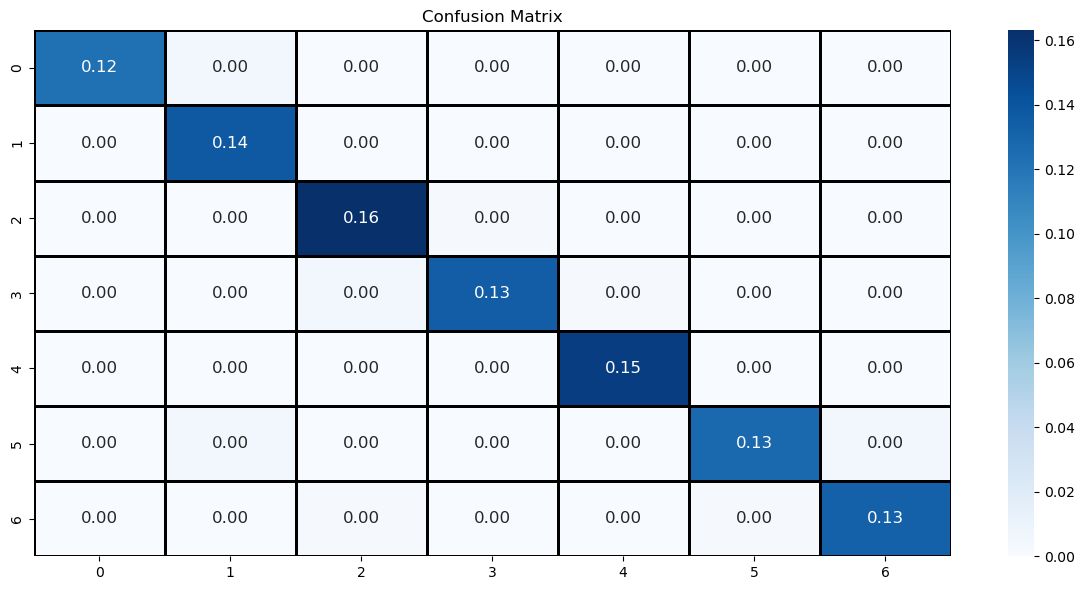

In [33]:
cm = confusion_matrix(y_test, pipeline.predict(X_test), normalize='all')

plt.figure(figsize=(12,6))
sns.heatmap(data=cm, cmap='Blues', annot=True, annot_kws={'size': 12}, fmt='.2f', linecolor='k', linewidths=1)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

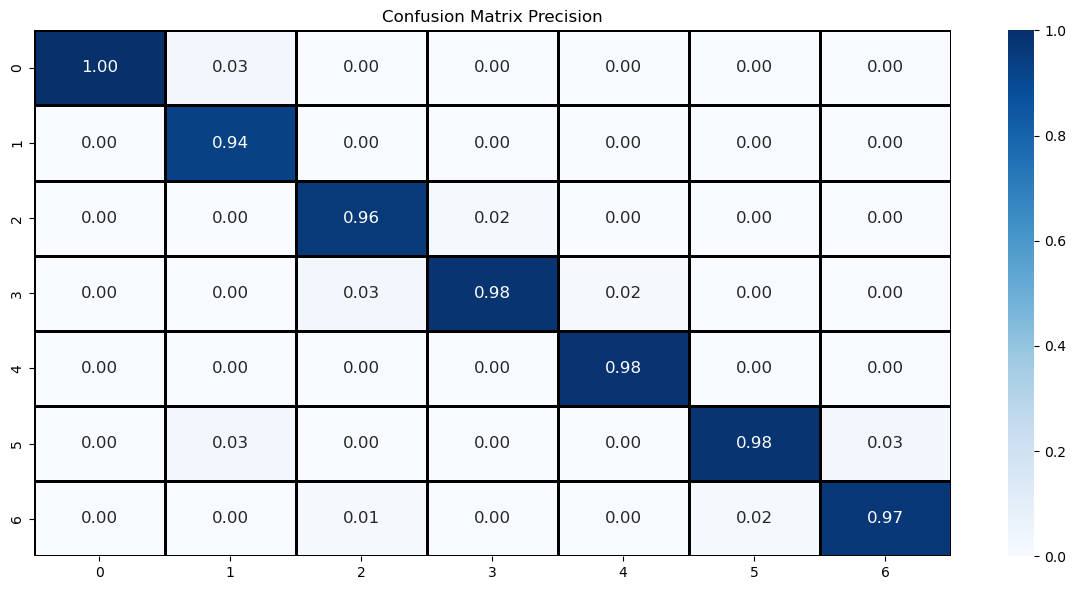

In [34]:
plt.figure(figsize=(12,6))
cm = confusion_matrix(y_test, pipeline.predict(X_test), normalize='pred')
sns.heatmap(data=cm, cmap='Blues', annot=True, annot_kws={'size': 12}, fmt='.2f', linecolor='k', linewidths=1)
plt.title('Confusion Matrix Precision')
plt.tight_layout()
plt.show()

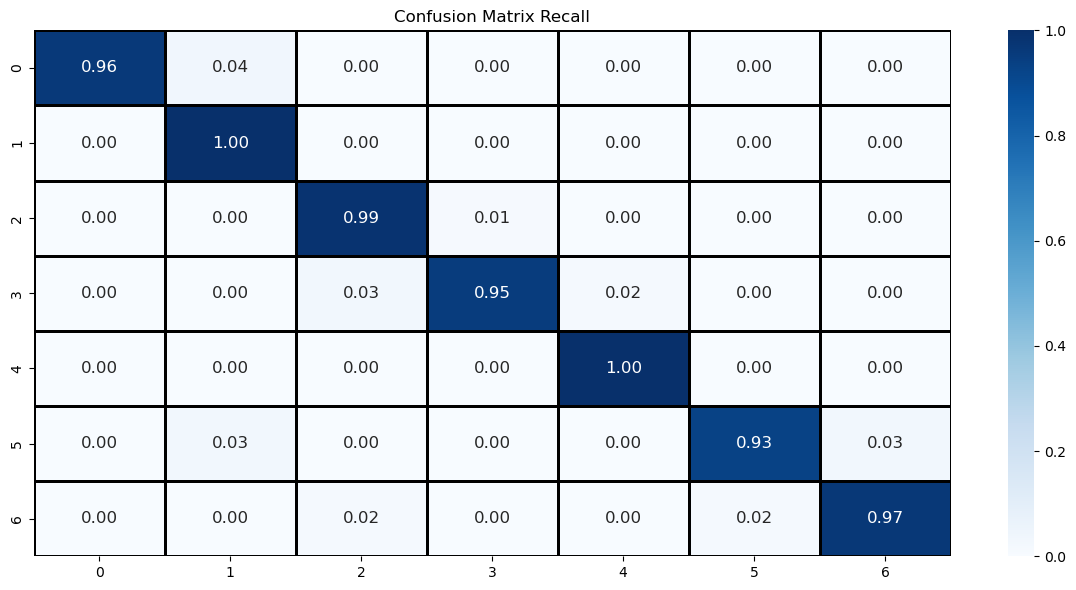

In [35]:
plt.figure(figsize=(12,6))
cm = confusion_matrix(y_test, pipeline.predict(X_test), normalize='true')
sns.heatmap(data=cm, cmap='Blues', annot=True, annot_kws={'size': 12}, fmt='.2f', linecolor='k', linewidths=1)
plt.title('Confusion Matrix Recall')
plt.tight_layout()
plt.show()

The off diagonal in recall shows false negative which the model missed

and in precision it means false positive which model mistakenly predicted as yes

In [36]:
report =pd.DataFrame(
    data=classification_report(
        y_test, pipeline.predict(X_test),
        output_dict=True
    )
).T

report.columns.name = 'Classification Report'
report

Classification Report,precision,recall,f1-score,support
Insufficient_Weight,1.000000,0.962963,0.981132,54.000000
Normal_Weight,0.935484,1.000000,0.966667,58.000000
Obesity_Type_I,0.958333,0.985714,0.971831,70.000000
Obesity_Type_II,0.982759,0.950000,0.966102,60.000000
Obesity_Type_III,0.984848,1.000000,0.992366,65.000000
Overweight_Level_I,0.981818,0.931034,0.955752,58.000000
Overweight_Level_II,0.965517,0.965517,0.965517,58.000000
accuracy,0.971631,0.971631,0.971631,0.971631
macro avg,0.972680,0.970747,0.971338,423.000000
weighted avg,0.972264,0.971631,0.971583,423.000000


In [37]:
pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', DecisionTreeClassifier(criterion='entropy', max_depth=3)),
    ])

param_grid = {
    'model__min_samples_split': [3, 15, 25],
    'model__min_samples_leaf': [3, 10, 25], 
    'model__max_depth': [5, 10, 20],
    'model__max_features': [3, 8, 10]
}

skfolds = StratifiedKFold(n_splits=5, shuffle=True)

grid_search = GridSearchCV(
    pipeline, param_grid,
    scoring='f1_macro',
    cv=skfolds,
)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...ax_depth=3))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__max_features': [3, 8, ...], 'model__min_samples_leaf': [3, 10, ...], 'model__min_samples_split': [3, 15, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Ordinal', ...), ('Nominal', ...)]"


In [38]:
grid_search.best_score_

np.float64(0.9588076052220927)

In [39]:
grid_search.best_params_

{'model__max_depth': 20,
 'model__max_features': 10,
 'model__min_samples_leaf': 10,
 'model__min_samples_split': 25}

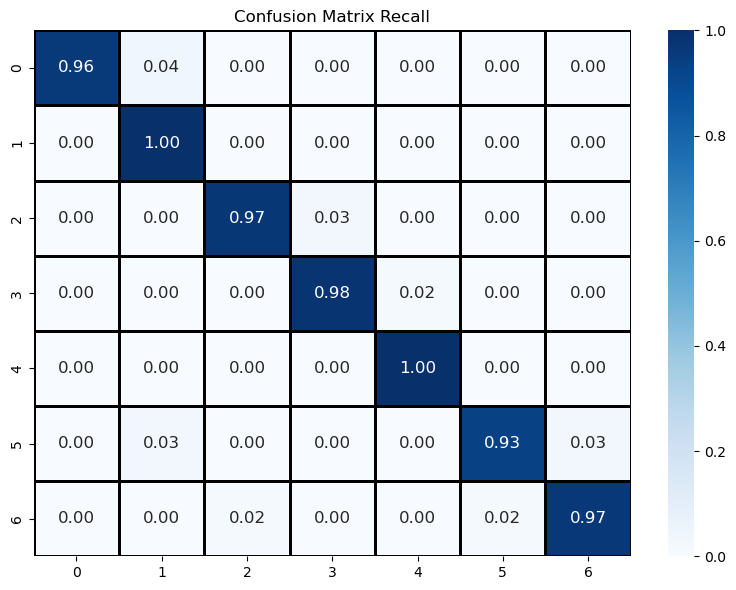

In [40]:
cm = confusion_matrix(y_test, grid_search.best_estimator_.predict(X_test), normalize='true')
plt.figure(figsize=(8,6))
sns.heatmap(data=cm, cmap='Blues', annot=True, annot_kws={'size': 12}, fmt='.2f', linecolor='k', linewidths=1)
plt.title('Confusion Matrix Recall')
plt.tight_layout()
plt.show()

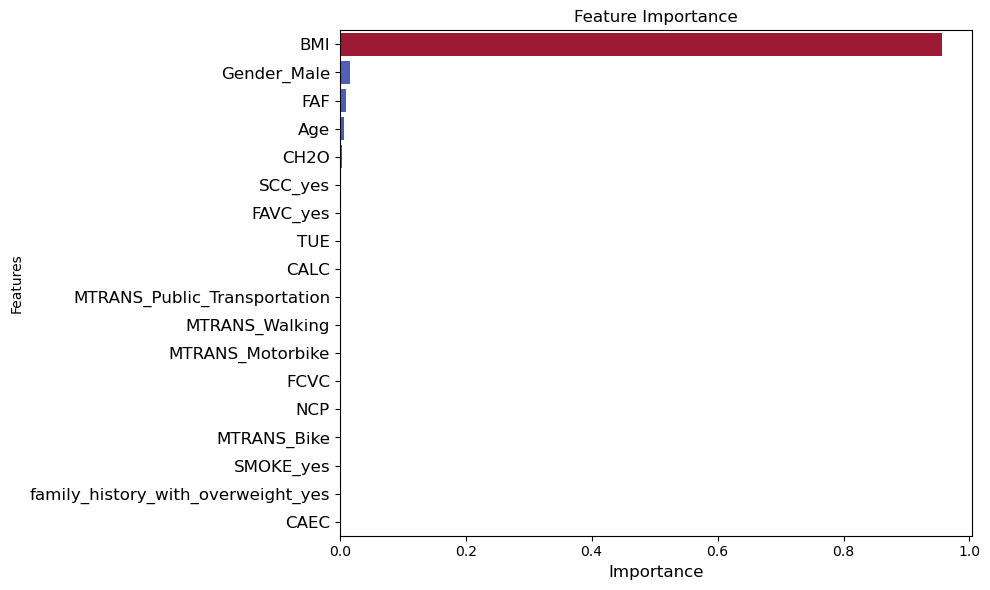

In [41]:
model = grid_search.best_estimator_
feature_names = model.named_steps['preprocessing'].get_feature_names_out()
feature_imp = model.named_steps['model'].feature_importances_

feature_df = pd.DataFrame(
    data={
        'Features': feature_names,
        'Importance': feature_imp
    }
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_df, y='Features', x='Importance',
    order=feature_df.sort_values(by='Importance', ascending=False)['Features'],
    hue='Importance',
    palette='coolwarm',
    legend=False
)
plt.title('Feature Importance', fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

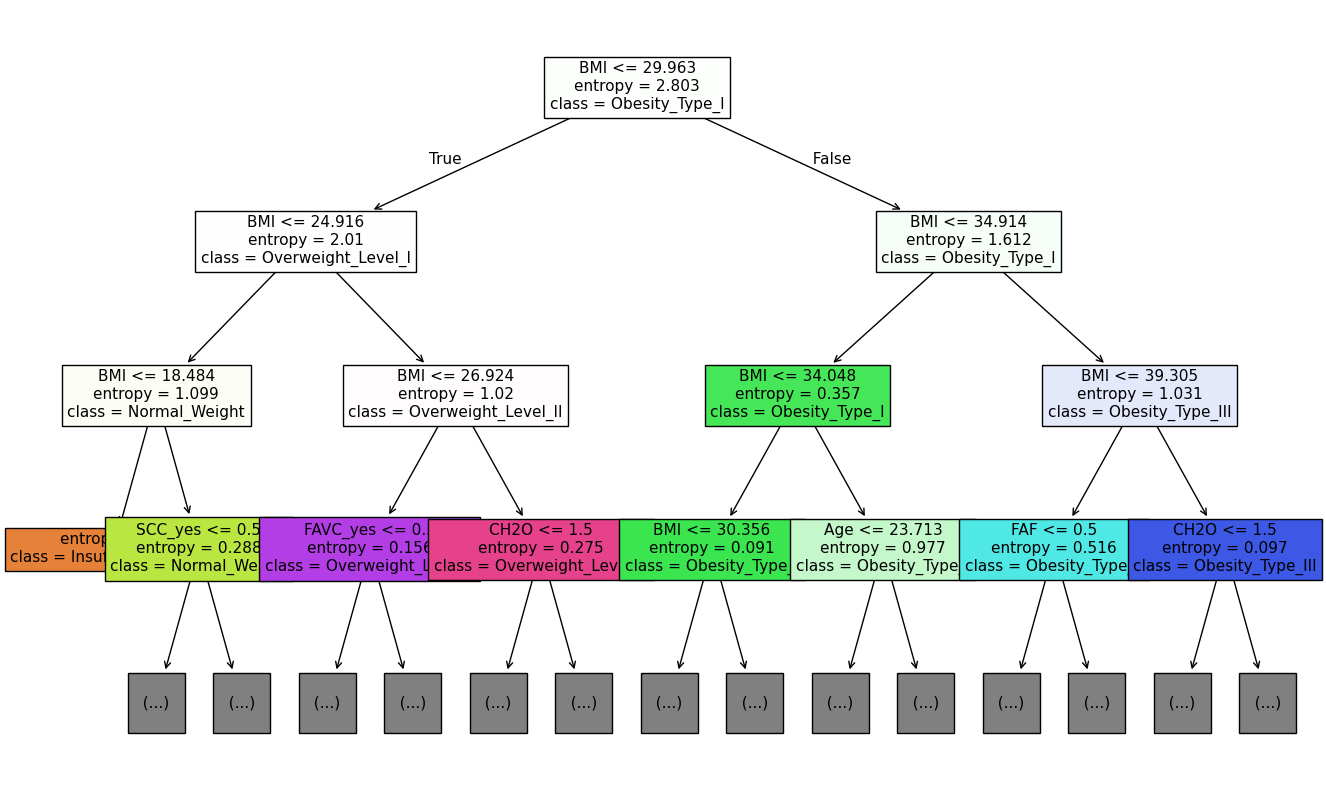

In [47]:
import re
fig, ax = plt.subplots(figsize=(16, 10)) 
annotations = plot_tree( 
    model.named_steps['model'], 
    feature_names=feature_names, 
    class_names=model.named_steps['model'].classes_, 
    max_depth=3, 
    filled=True, 
    fontsize=11, 
    label='all', 
    ax=ax 
)

for annotation in annotations:
    text = annotation.get_text()

    text = re.sub(r'samples\s*=\s*\d+\n?', '', text)
    text = re.sub(r'value\s*=\s*\[.*?\]\n?', '', text)
    annotation.set_text(text)

plt.show()


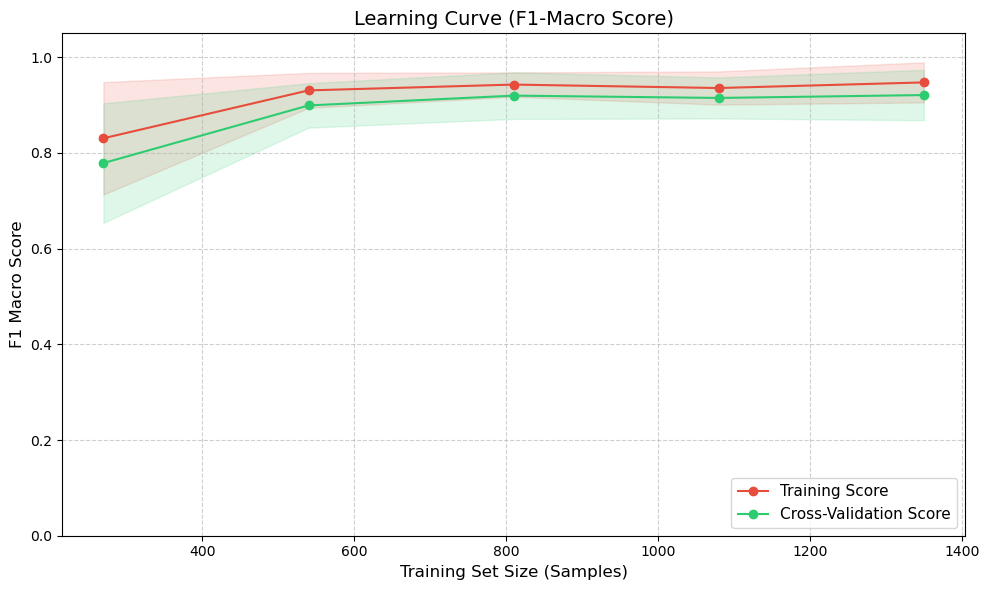

In [44]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train,
        cv=skfolds,
        scoring='f1_macro',
        train_sizes=np.linspace(0.2, 1.0, 5)
    )


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, test_mean, 'o-', color='#2ecc71', label='Cross-Validation Score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#2ecc71')
plt.title('Learning Curve (F1-Macro Score)', fontsize=14)
plt.xlabel('Training Set Size (Samples)', fontsize=12)
plt.ylabel('F1 Macro Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()

In [45]:
report =pd.DataFrame(
    data=classification_report(
        y_test, model.predict(X_test),
        output_dict=True
    )
).T

report.columns.name = 'Classification Report'
report

Classification Report,precision,recall,f1-score,support
Insufficient_Weight,1.000000,0.962963,0.981132,54.000000
Normal_Weight,0.935484,1.000000,0.966667,58.000000
Obesity_Type_I,0.985507,0.971429,0.978417,70.000000
Obesity_Type_II,0.967213,0.983333,0.975207,60.000000
Obesity_Type_III,0.984848,1.000000,0.992366,65.000000
Overweight_Level_I,0.981818,0.931034,0.955752,58.000000
Overweight_Level_II,0.965517,0.965517,0.965517,58.000000
accuracy,0.973995,0.973995,0.973995,0.973995
macro avg,0.974341,0.973468,0.973580,423.000000
weighted avg,0.974555,0.973995,0.973964,423.000000
